Colour gradient score: 1.0842873740495613


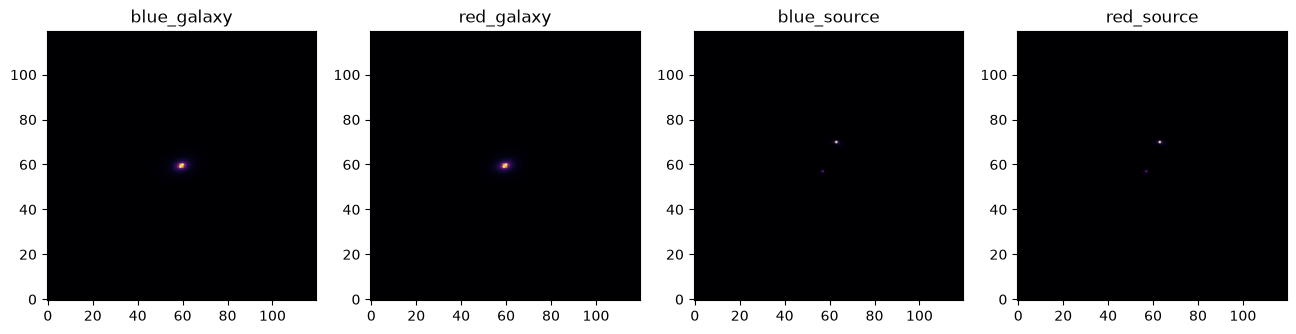

In [4]:
import sys
import matplotlib.pyplot as plt
import numpy as np
sys.path.append('../src')
import head_labels
import importlib
importlib.reload(head_labels)
from head_labels import render_two_band_signal, colour_gradient_score, einstein_ring_score, brightness_asymmetry_score

import lens_injector
importlib.reload(lens_injector)
from lens_injector import generate_lens_signal_raw

test_lens = generate_lens_signal_raw(numPix=120, pixel_scale=0.168, is_lens=True, seed=42)

kwargs_lens_test = [{'theta_E': test_lens['metadata']['theta_E'], 'e1': test_lens['metadata']['e1_lens'],
                      'e2': test_lens['metadata']['e2_lens'], 'center_x': 0.0, 'center_y': 0.0}]
kwargs_lens_light_test = [{'amp': test_lens['metadata']['amp_lens_light'], 'R_sersic': test_lens['metadata']['R_sersic_lens_light'],
                            'n_sersic': 4, 'e1': test_lens['metadata']['e1_lens'], 'e2': test_lens['metadata']['e2_lens'],
                            'center_x': 0.0, 'center_y': 0.0}]
kwargs_source_test = [{'amp': 100, 'R_sersic': test_lens['metadata']['R_sersic_source'], 'n_sersic': test_lens['metadata']['n_sersic_source'],
                        'e1': test_lens['metadata']['e1_source'], 'e2': test_lens['metadata']['e2_source'],
                        'center_x': test_lens['metadata']['source_x'], 'center_y': test_lens['metadata']['source_y']}]

two_band_result = render_two_band_signal(kwargs_lens_test, kwargs_lens_light_test, kwargs_source_test,
                                            lens_model_list=['SIE'], numPix=120, pixel_scale=0.168, seed=100)

color_score = colour_gradient_score(two_band_result)
print("Colour gradient score:", color_score)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ['blue_galaxy', 'red_galaxy', 'blue_source', 'red_source']
for ax, title in zip(axes, titles):
    ax.imshow(two_band_result[title], cmap='inferno', origin='lower')
    ax.set_title(title)
plt.show()

In [5]:
print("Galaxy blue flux:", np.sum(two_band_result['blue_galaxy']))
print("Galaxy red flux:", np.sum(two_band_result['red_galaxy']))
print("Source blue flux:", np.sum(two_band_result['blue_source']))
print("Source red flux:", np.sum(two_band_result['red_source']))

Galaxy blue flux: 1315.6731045189922
Galaxy red flux: 4136.334574311814
Source blue flux: 204.73564419167406
Source red flux: 53.0119462101957


Arc geometry score: (np.float64(0.7325337976954783), 2)
Einstein ring score: 0.5203248364967852
Brightness asymmetry score: 1.827737022572942


TypeError: unsupported format string passed to tuple.__format__

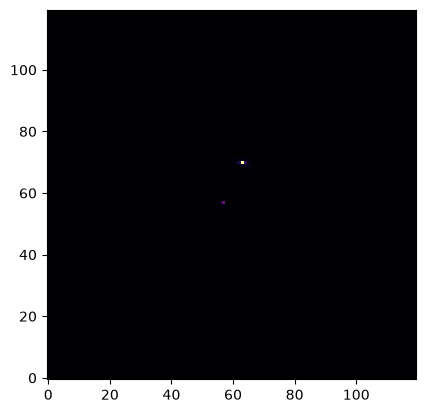

In [6]:
importlib.reload(head_labels)
from head_labels import render_two_band_signal, colour_gradient_score, einstein_ring_score, brightness_asymmetry_score, arc_geometry_score
isolated_arc = test_lens['signal'] - test_lens['galaxy_only_signal']

arc_score = arc_geometry_score(isolated_arc)
ring_score = einstein_ring_score(test_lens['metadata']['theta_E'],
                                   np.sqrt(test_lens['metadata']['source_x']**2 + test_lens['metadata']['source_y']**2))
asym_score = brightness_asymmetry_score(isolated_arc)

print("Arc geometry score:", arc_score)
print("Einstein ring score:", ring_score)
print("Brightness asymmetry score:", asym_score)

plt.imshow(isolated_arc, cmap='inferno', origin='lower')
plt.title(f"Isolated arc (elongation={arc_score:.3f}, ring={ring_score:.3f})")
plt.colorbar()
plt.show()

Elongation: 0.096009455703017 Components: 2 Ring score: 0.2577894858866897


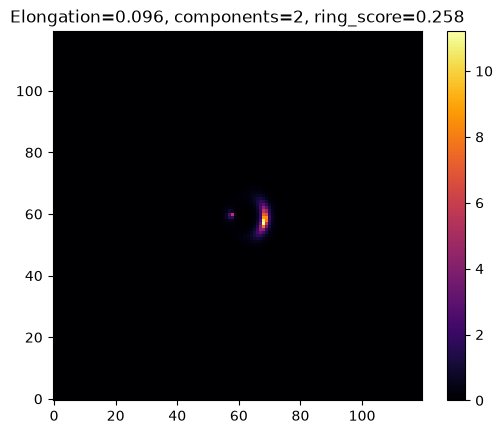

In [7]:
test_lens_ring = generate_lens_signal_raw(numPix=120, pixel_scale=0.168, is_lens=True, seed=7)
isolated_arc_ring = test_lens_ring['signal'] - test_lens_ring['galaxy_only_signal']

arc_score_ring, n_components_ring = arc_geometry_score(isolated_arc_ring)
ring_score_ring = einstein_ring_score(test_lens_ring['metadata']['theta_E'],
                                        np.sqrt(test_lens_ring['metadata']['source_x']**2 + test_lens_ring['metadata']['source_y']**2))

print("Elongation:", arc_score_ring, "Components:", n_components_ring, "Ring score:", ring_score_ring)

plt.imshow(isolated_arc_ring, cmap='inferno', origin='lower')
plt.title(f"Elongation={arc_score_ring:.3f}, components={n_components_ring}, ring_score={ring_score_ring:.3f}")
plt.colorbar()
plt.show()